## Test Notebook For NIXTLA NeuralForecast

really simple test of using the API but on here https://nixtlaverse.nixtla.io/neuralforecast/docs/tutorials/getting_started_complete.html there is an even more fun tutorial, where they also suggest rolling windowing for time series forecasting, etc...

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

In [2]:
dates = pd.date_range("2023-01-01", periods=120, freq="D")

df_list = []
for i, uid in enumerate(["H1", "H2", "H3"]):
    base = 10 + i * 3
    values = []
    for t in range(len(dates)):
        # simple synthetic pattern: level + weekly seasonality + slight trend
        y = base + 2 * ((t % 7) in [5, 6]) + 0.03 * t
        values.append(float(y))
    tmp = pd.DataFrame({
        "unique_id": uid,
        "ds": dates,
        "y": values
    })
    df_list.append(tmp)

Y_df = pd.concat(df_list, ignore_index=True)
display(Y_df)

,unique_id,ds,y
0,H1,2023-01-01,10.00
1,H1,2023-01-02,10.03
2,H1,2023-01-03,10.06
3,H1,2023-01-04,10.09
4,H1,2023-01-05,10.12
...,...,...,...
355,H3,2023-04-26,19.45
356,H3,2023-04-27,19.48
357,H3,2023-04-28,21.51
358,H3,2023-04-29,21.54


In [3]:
h = 14

train_df = Y_df.groupby("unique_id").head(len(dates) - h).reset_index(drop=True)
test_df  = Y_df.groupby("unique_id").tail(h).reset_index(drop=True)

print(train_df.shape, test_df.shape)

(318, 3) (42, 3)


In [4]:
# simple NN
model = NHITS(
    h=h,
    input_size=28,   # use last 28 observations to predict next 14
    max_steps=100,   # keep small for a quick demo
)

nf = NeuralForecast(
    models=[model],
    freq="D"
)

nf.fit(df=train_df)

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/gandalf/Documents/github-repos/Clustering-And-Forecasting-TimeSeries-PlayingGround/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.


In [5]:
preds = nf.predict()
preds.head()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/gandalf/Documents/github-repos/Clustering-And-Forecasting-TimeSeries-PlayingGround/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,NHITS
0,H1,2023-04-17,13.218225
1,H1,2023-04-18,13.123852
2,H1,2023-04-19,13.172206
3,H1,2023-04-20,13.551492
4,H1,2023-04-21,13.735441


In [ ]:
# Join predictions with actual test values
result = test_df.merge(preds, on=["unique_id", "ds"], how="left")
result.head()

In [ ]:
forecast_col = [c for c in result.columns if c not in ["unique_id", "ds", "y"]][0]

mae_per_series = (
    result.assign(abs_err=lambda x: (x["y"] - x[forecast_col]).abs())
          .groupby("unique_id")["abs_err"]
          .mean()
          .reset_index(name="MAE")
)

print(mae_per_series)
print("Overall MAE:", mae_per_series["MAE"].mean())

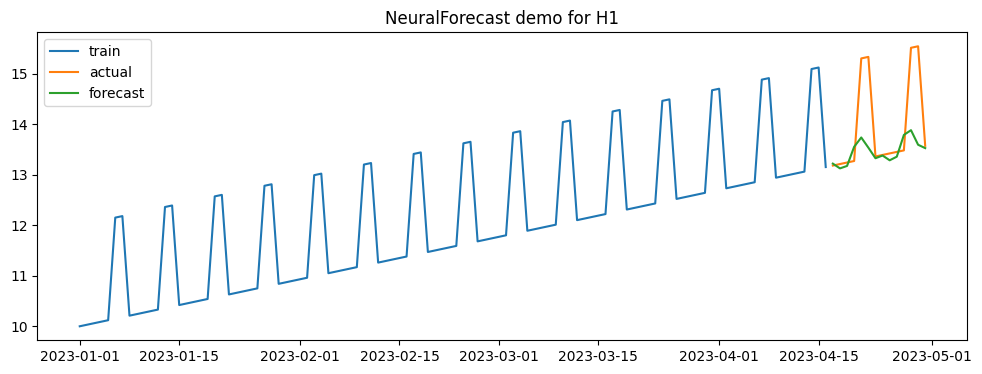

In [18]:
uid = "H1"

hist = train_df[train_df["unique_id"] == uid]
future = result[result["unique_id"] == uid]

plt.figure(figsize=(12, 4))
plt.plot(hist["ds"], hist["y"], label="train")
plt.plot(future["ds"], future["y"], label="actual")
plt.plot(future["ds"], future[forecast_col], label="forecast")
plt.title(f"NeuralForecast demo for {uid}")
plt.legend()
plt.show()